# Mercury Perihelion Precession with Baseline Correction

A standalone Mercury precession study that subtracts numerical baseline drift and extrapolates a modified-force parameter.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


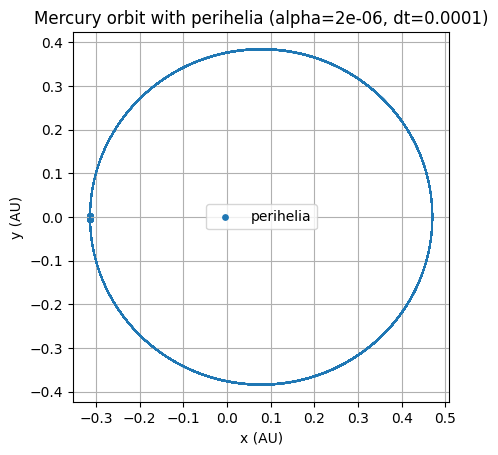

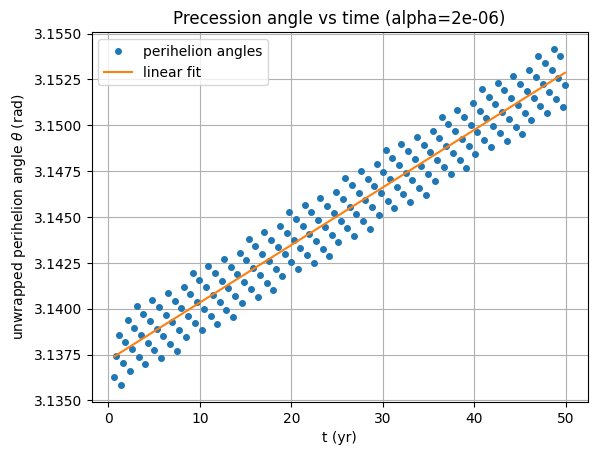

alpha values used: [0.e+00 1.e-06 2.e-06 5.e-06 1.e-05 2.e-05 5.e-05 1.e-04]
rates (deg/yr): [-0.00267531  0.00753153  0.01797987  0.04924246  0.10085072  0.20475641
  0.51630122  1.0363356 ]

Baseline numerical rate at alpha=0: -0.002675305310549002 deg/yr
Baseline-corrected slope m0 = 1.038718e+04 (deg/yr)/AU^2
Mercury GR precession: 1.142589e-04 deg/yr
=  41.133 arcsec/century


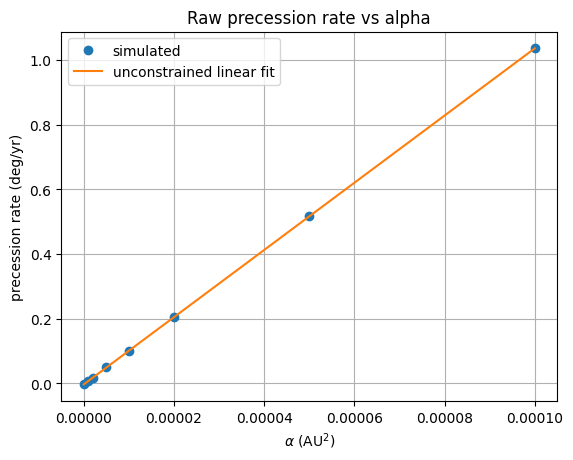

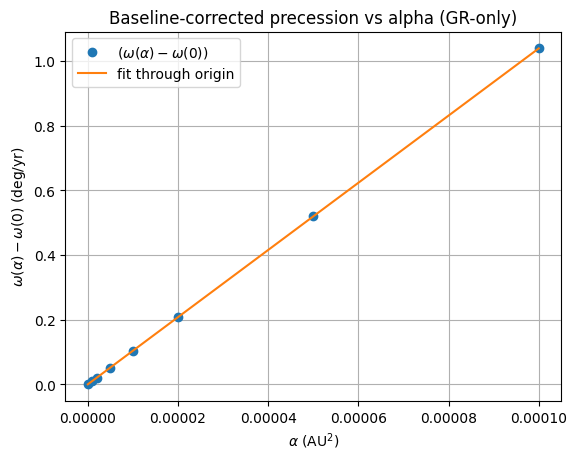

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PI = np.pi
GM = 4.0 * PI**2  # AU^3 / yr^2

# Mercury initial conditions (perihelion start)
r_peri = 0.47     # AU
v_peri = 8.2      # AU/yr

# Mercury GR parameter (AU^2)
alpha_mercury = 1.1e-8


def integrate_mercury(alpha=0.0, dt=1e-4, Ttot=50.0):
    """
    Integrate Mercury orbit with GR-like correction:
      r'' = -GM * r_vec / r^3 * (1 + alpha/r^2)
    using Euler–Cromer.
    """
    n = int(Ttot / dt) + 1
    t = np.arange(n) * dt

    x  = np.zeros(n); y  = np.zeros(n)
    vx = np.zeros(n); vy = np.zeros(n)

    # Start at perihelion on +x axis, tangential velocity +y
    x[0], y[0] = r_peri, 0.0
    vx[0], vy[0] = 0.0, v_peri

    for i in range(n - 1):
        r = np.hypot(x[i], y[i])
        fac = -GM * (1.0 + alpha / (r * r)) / (r**3)
        ax = fac * x[i]
        ay = fac * y[i]

        # Euler–Cromer update
        vx[i+1] = vx[i] + ax * dt
        vy[i+1] = vy[i] + ay * dt
        x[i+1]  = x[i]  + vx[i+1] * dt
        y[i+1]  = y[i]  + vy[i+1] * dt

    r = np.hypot(x, y)
    return t, x, y, r


def find_perihelia_indices(r):
    """
    Local minima: r[i-1] > r[i] < r[i+1]
    """
    return np.where((r[1:-1] < r[:-2]) & (r[1:-1] < r[2:]))[0] + 1


def precession_rate(alpha, dt=1e-4, Ttot=50.0, skip_first=2, make_plots=False):
    """
    For a given alpha:
      - integrate orbit
      - find perihelia
      - compute perihelion angles theta_k = atan2(y,x)
      - unwrap theta_k
      - fit theta(t) = omega t + b
    Return rate in deg/yr.
    """
    t, x, y, r = integrate_mercury(alpha=alpha, dt=dt, Ttot=Ttot)
    idx = find_perihelia_indices(r)

    if len(idx) < (skip_first + 6):
        raise RuntimeError("Not enough perihelia found; increase Ttot or decrease dt.")

    idx = idx[skip_first:]
    tp = t[idx]
    theta = np.arctan2(y[idx], x[idx])
    theta = np.unwrap(theta)

    # Linear least squares fit: theta = omega t + b
    A = np.vstack([tp, np.ones_like(tp)]).T
    omega, b = np.linalg.lstsq(A, theta, rcond=None)[0]

    rate_deg_per_yr = omega * (180.0 / np.pi)

    if make_plots:
        # Orbit + perihelia markers
        plt.figure()
        plt.plot(x, y, lw=1)
        plt.scatter(x[idx], y[idx], s=15, label="perihelia")
        plt.gca().set_aspect("equal", adjustable="box")
        plt.xlabel("x (AU)"); plt.ylabel("y (AU)")
        plt.title(f"Mercury orbit with perihelia (alpha={alpha:g}, dt={dt:g})")
        plt.grid(True); plt.legend()
        plt.show()

        # theta(t) + fit
        plt.figure()
        plt.plot(tp, theta, "o", ms=4, label="perihelion angles")
        plt.plot(tp, omega*tp + b, label="linear fit")
        plt.xlabel("t (yr)")
        plt.ylabel(r"unwrapped perihelion angle $\theta$ (rad)")
        plt.title(f"Precession angle vs time (alpha={alpha:g})")
        plt.grid(True); plt.legend()
        plt.show()

    return rate_deg_per_yr


# -------------------------
# MAIN: rate vs alpha, baseline-correct, extrapolate
# -------------------------
dt = 1e-4
Ttot = 50.0

# Use small exaggerated alphas (near-linear regime)
alpha_list = np.array([0.0, 1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, 1e-4])

rates = []
for a in alpha_list:
    # Make diagnostic plots for one representative alpha (optional)
    make_plots = (a == 2e-6)
    rates.append(precession_rate(a, dt=dt, Ttot=Ttot, skip_first=2, make_plots=make_plots))
rates = np.array(rates)

print("alpha values used:", alpha_list)
print("rates (deg/yr):", rates)

# -------------------------
# BASELINE CORRECTION (THIS IS THE IMPORTANT FIX)
# -------------------------
rate0 = rates[0]                 # numerical precession at alpha=0 (artifact)
rates_corr = rates - rate0        # GR-only contribution relative to alpha=0

# Fit THROUGH ORIGIN: rates_corr ≈ m0 * alpha
# (This is the physically correct small-alpha behavior)
m0 = np.sum(alpha_list * rates_corr) / np.sum(alpha_list**2)

# Extrapolate to Mercury alpha
rate_mercury_deg_per_yr = m0 * alpha_mercury
rate_mercury_arcsec_per_cent = rate_mercury_deg_per_yr * 3600.0 * 100.0

print("\nBaseline numerical rate at alpha=0:", rate0, "deg/yr")
print("Baseline-corrected slope m0 =", f"{m0:.6e}", "(deg/yr)/AU^2")
print("Mercury GR precession:", f"{rate_mercury_deg_per_yr:.6e}", "deg/yr")
print("= ", f"{rate_mercury_arcsec_per_cent:.3f}", "arcsec/century")

# -------------------------
# Plot 1: raw rate vs alpha (shows small intercept artifact)
# -------------------------
m_raw, c_raw = np.polyfit(alpha_list, rates, 1)
aa = np.linspace(alpha_list.min(), alpha_list.max(), 200)

plt.figure()
plt.plot(alpha_list, rates, "o", label="simulated")
plt.plot(aa, m_raw*aa + c_raw, label="unconstrained linear fit")
plt.xlabel(r"$\alpha$ (AU$^2$)")
plt.ylabel("precession rate (deg/yr)")
plt.title("Raw precession rate vs alpha")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# Plot 2: baseline-corrected rate vs alpha (should go through origin)
# -------------------------
plt.figure()
plt.plot(alpha_list, rates_corr, "o", label=r"$(\omega(\alpha)-\omega(0))$")
plt.plot(aa, m0*aa, label="fit through origin")
plt.xlabel(r"$\alpha$ (AU$^2$)")
plt.ylabel(r"$\omega(\alpha)-\omega(0)$ (deg/yr)")
plt.title("Baseline-corrected precession vs alpha (GR-only)")
plt.grid(True)
plt.legend()
plt.show()
